In [4]:
%matplotlib widget   

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d, fftconvolve
from tqdm import tqdm


In [ ]:


# Directory with the test DN maps
folder = r"C:\Users\Owner\Documents\Hirata Group\Code\python\Outputs\BFE tests"
# List all the npy files for DN maps (edit filter if needed)
dnmap_files = [f for f in os.listdir(folder) if f.startswith("DNmap") and f.endswith(".npy")]

means = []
norm_frames = []

def mean_subtracted_autocorr(frame):
    f = frame - np.mean(frame)
    acf = correlate2d(f, f, mode='full')
    return acf / np.max(np.abs(acf))  # Normalize peak to 1

# Loop through files, compute mean, and (optionally) keep normalized versions
for fname in tqdm(dnmap_files, desc="Processing DN map..."):
    frame = np.load(os.path.join(folder, fname), mmap_mode='r')  # mmap to be extra safe
    mean_DN = np.mean(frame)
    means.append(mean_DN)
    norm_frames.append((frame - mean_DN).astype(np.float32)) # Optionally keep a normalized version for later

means = np.array(means)
print("Mean DNs per frame:", means)
print("Mean of means:", np.mean(means))


In [ ]:
# Sort frames and means by mean DN
sorted_indices = np.argsort(means)
means_sorted = means[sorted_indices]
norm_frames_sorted = [norm_frames[i] for i in sorted_indices]

print("Sorted mean DNs:", means_sorted)

In [ ]:
# Define bin edges (choose based on your distribution)
bin_edges = [0, 1, 2, np.inf]
bin_labels = ['low', 'med', 'high']
digitized = np.digitize(means_sorted, bin_edges)

binned_frames = {label: [] for label in bin_labels}
for idx, label in zip(range(len(norm_frames_sorted)), digitized):
    binned_frames[bin_labels[label-1]].append(norm_frames_sorted[idx])

for label in bin_labels:
    print(f"Frames in {label} bin:", len(binned_frames[label]))


In [2]:
def mean_subtracted_autocorr_fft(frame):
    f = frame - np.mean(frame)
    acf = fftconvolve(f, f[::-1, ::-1], mode='full')
    acf /= np.max(np.abs(acf))
    return acf.astype(np.float32)

# ---- Parameters ----

folder = r"C:\Users\Owner\Documents\Hirata Group\Code\python\Outputs\BFE tests"
dnmap_files = [f for f in os.listdir(folder) if f.startswith("DNmap") and f.endswith(".npy")]

bin_edges = [0, 1, 2, np.inf]
bin_labels = ['low', 'med', 'high']

# ---- Load, normalize, sort, and bin ----

means = []
norm_frames = []

for fname in tqdm(dnmap_files, desc="Loading frames"):
    frame = np.load(os.path.join(folder, fname), mmap_mode='r')
    mean_DN = np.mean(frame)
    means.append(mean_DN)
    norm_frames.append((frame - mean_DN).astype(np.float32))

means = np.array(means)
sorted_indices = np.argsort(means)
means_sorted = means[sorted_indices]
norm_frames_sorted = [norm_frames[i] for i in sorted_indices]

digitized = np.digitize(means_sorted, bin_edges)
binned_frames = {label: [] for label in bin_labels}
for idx, label_idx in enumerate(digitized):
    binned_frames[bin_labels[label_idx-1]].append(norm_frames_sorted[idx])

for label in bin_labels:
    print(f"Frames in {label} bin:", len(binned_frames[label]))




Loading frames: 100%|██████████| 9/9 [00:05<00:00,  1.55it/s]

Frames in low bin: 3
Frames in med bin: 4
Frames in high bin: 2


In [5]:
# ---- FFT-based autocorrelation per bin (no cropping) ----

bin_avg_acfs = {}

for label, frames_in_bin in binned_frames.items():
    print(f"Processing bin: {label} with {len(frames_in_bin)} frames")
    acfs = []
    for norm in tqdm(frames_in_bin, desc=f"Autocorr (FFT) '{label}'"):
        acf = mean_subtracted_autocorr_fft(norm)
        acfs.append(acf)
    if acfs:
        avg_acf = np.mean(acfs, axis=0)
        bin_avg_acfs[label] = avg_acf
    else:
        bin_avg_acfs[label] = None


Processing bin: low with 3 frames


Autocorr (FFT) 'low': 100%|██████████| 3/3 [00:08<00:00,  2.71s/it]


Processing bin: med with 4 frames


Autocorr (FFT) 'med': 100%|██████████| 4/4 [00:09<00:00,  2.38s/it]


Processing bin: high with 2 frames


Autocorr (FFT) 'high': 100%|██████████| 2/2 [00:04<00:00,  2.39s/it]


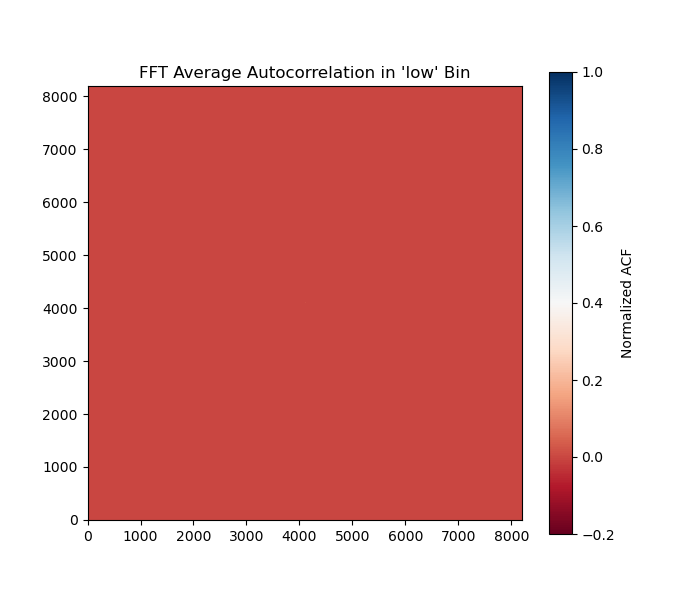

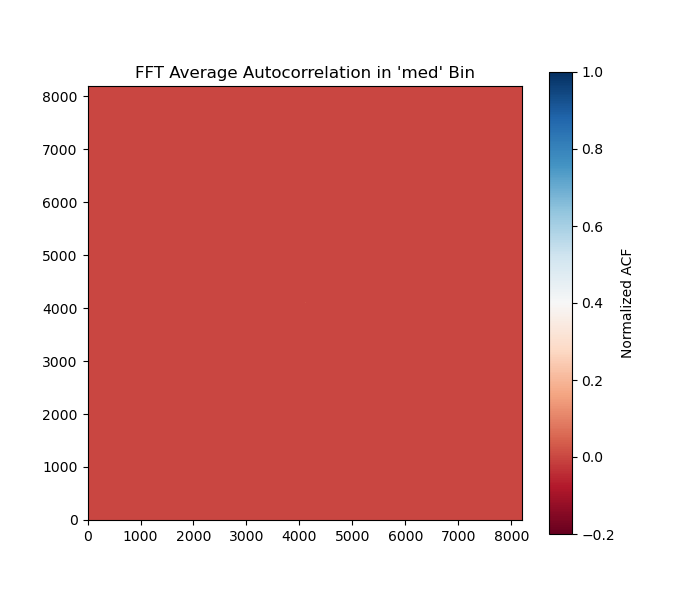

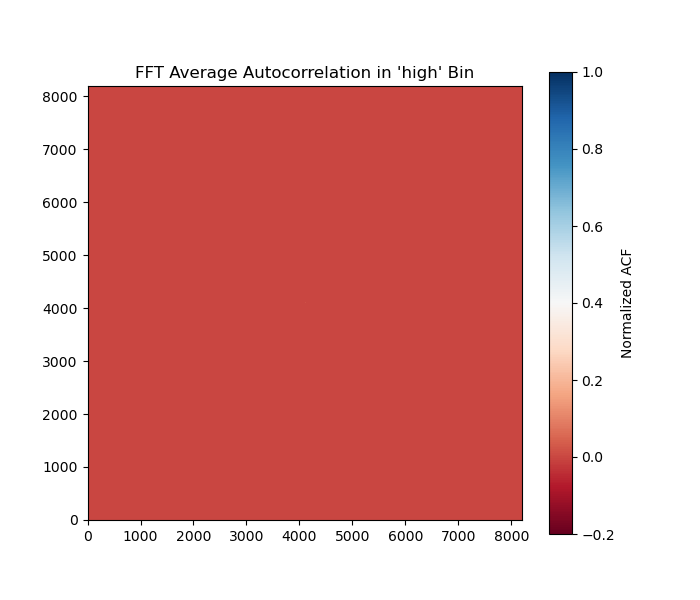

In [6]:
# ---- Plot ----

for label, avg_acf in bin_avg_acfs.items():
    if avg_acf is not None:
        plt.figure(figsize=(7,6))
        plt.imshow(avg_acf, origin='lower', cmap='RdBu', vmin=-0.2, vmax=1)
        plt.title(f"FFT Average Autocorrelation in '{label}' Bin")
        plt.colorbar(label="Normalized ACF")
        plt.show()
    else:
        print(f"No frames in '{label}' bin; skipping plot.")


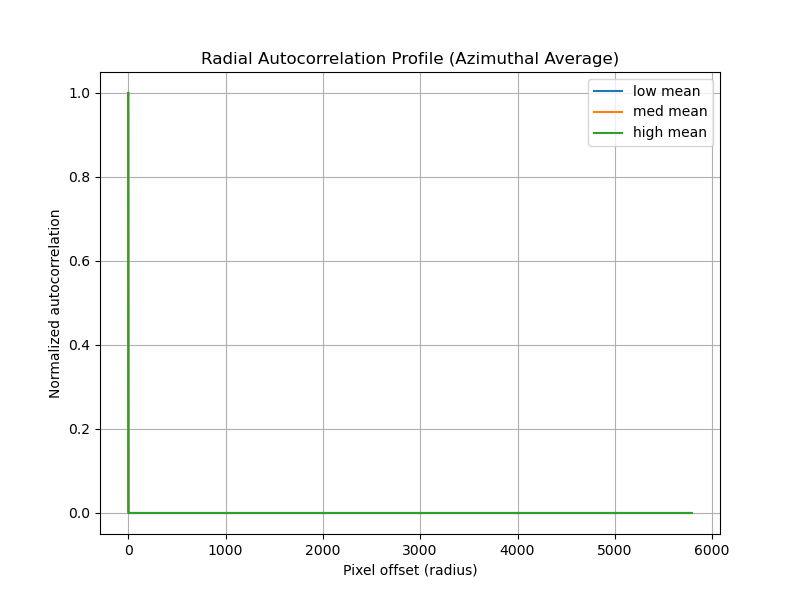

In [7]:
def radial_profile(acf):
    """Compute the radial profile (azimuthal average) of a 2D array."""
    y, x = np.indices(acf.shape)
    center = np.array(acf.shape) // 2
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r = r.astype(np.int32)
    tbin = np.bincount(r.ravel(), acf.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / nr
    return radialprofile

# For your three binned outputs:
plt.figure(figsize=(8,6))
for label, avg_acf in bin_avg_acfs.items():
    if avg_acf is not None:
        profile = radial_profile(avg_acf)
        plt.plot(profile, label=f"{label} mean")
plt.xlabel("Pixel offset (radius)")
plt.ylabel("Normalized autocorrelation")
plt.title("Radial Autocorrelation Profile (Azimuthal Average)")
plt.legend()
plt.grid()
plt.show()


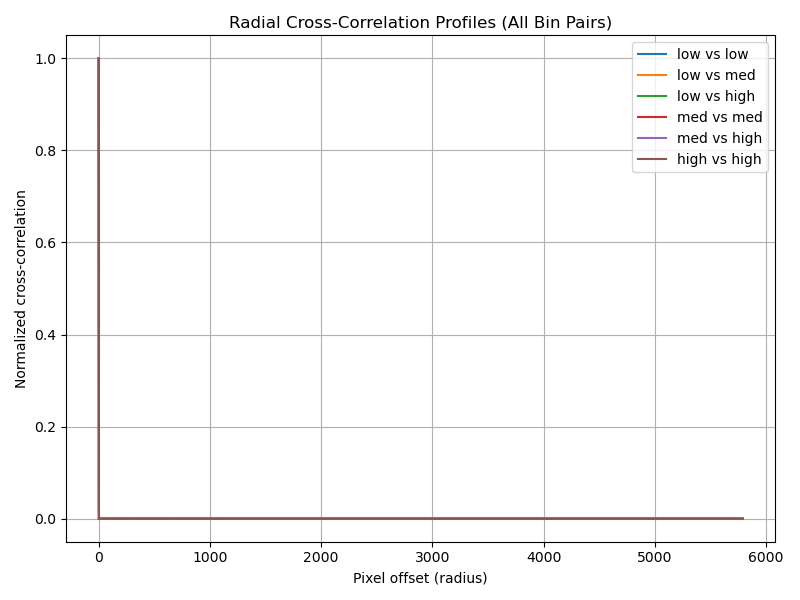

In [8]:
from itertools import combinations_with_replacement

# First, compute mean images for each bin (as above)
bin_means = {}
for label, frames in binned_frames.items():
    if frames:
        bin_means[label] = np.mean(frames, axis=0)
    else:
        bin_means[label] = None

def fft_crosscorr2d(a, b):
    """Cross-correlate two 2D arrays using FFT."""
    a = a - np.mean(a)
    b = b - np.mean(b)
    cc = fftconvolve(a, b[::-1, ::-1], mode='full')
    cc /= np.max(np.abs(cc))
    return cc.astype(np.float32)

# All possible pairs (with replacement for autocorr)
bin_pairs = list(combinations_with_replacement(bin_labels, 2))

plt.figure(figsize=(8,6))

for labelA, labelB in bin_pairs:
    meanA, meanB = bin_means[labelA], bin_means[labelB]
    if (meanA is not None) and (meanB is not None):
        cc = fft_crosscorr2d(meanA, meanB)
        cc_profile = radial_profile(cc)
        plt.plot(cc_profile, label=f"{labelA} vs {labelB}")

plt.xlabel("Pixel offset (radius)")
plt.ylabel("Normalized cross-correlation")
plt.title("Radial Cross-Correlation Profiles (All Bin Pairs)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [9]:
# Assuming: 
# - bin_avg_acfs is your dictionary of average autocorrelation maps per bin
# - means_sorted, digitized, and bin_labels are already defined as before

# Helper to extract neighbor correlation from a 2D ACF map
def neighbor_corr(acf, directions):
    center = np.array(acf.shape) // 2
    vals = []
    for d in directions:
        idx = tuple(center + np.array(d))
        vals.append(acf[idx])
    return vals

# Define directions for neighbors: 4-connected (right, left, up, down) and 8-connected (optionally)
directions_4 = [(-1,0), (1,0), (0,-1), (0,1)]  # up, down, left, right
directions_8 = directions_4 + [(-1,-1), (-1,1), (1,-1), (1,1)]  # add diagonals if desired

# Compute mean DN for each bin (mean of means of frames in that bin)
bin_mean_DNs = []
for label in bin_labels:
    bin_indices = np.where(digitized == (bin_labels.index(label)+1))[0]
    if len(bin_indices) > 0:
        bin_mean_DNs.append(np.mean(means_sorted[bin_indices]))
    else:
        bin_mean_DNs.append(np.nan)

# Compute neighbor correlations for each bin
nn_corrs = []
for label in bin_labels:
    acf = bin_avg_acfs[label]
    if acf is not None:
        neighbors = neighbor_corr(acf, directions_4)
        nn_corrs.append(np.mean(neighbors))  # average over the 4 neighbors
    else:
        nn_corrs.append(np.nan)


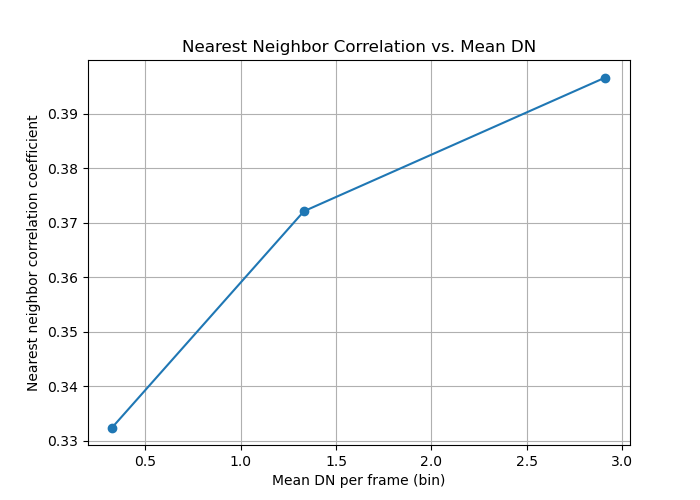

Bin:  low | Mean DN: 0.3266 | NN corr: 3.32392e-01
Bin:  med | Mean DN: 1.3316 | NN corr: 3.72085e-01
Bin: high | Mean DN: 2.9114 | NN corr: 3.96630e-01


In [10]:

# Plot
plt.figure(figsize=(7,5))
plt.plot(bin_mean_DNs, nn_corrs, marker='o')
plt.xlabel("Mean DN per frame (bin)")
plt.ylabel("Nearest neighbor correlation coefficient")
plt.title("Nearest Neighbor Correlation vs. Mean DN")
plt.grid(True)
plt.show()

# Optionally, print values
for label, m, c in zip(bin_labels, bin_mean_DNs, nn_corrs):
    print(f"Bin: {label:>4s} | Mean DN: {m:.4f} | NN corr: {c:.5e}")


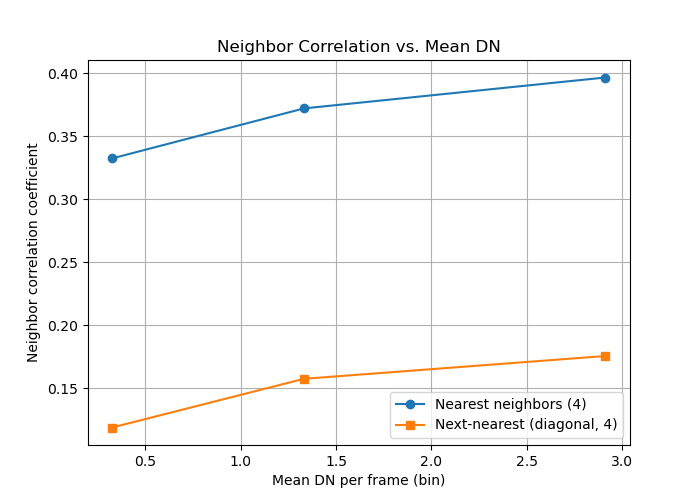

Bin:  low | Mean DN: 0.3266 | NN: 3.32392e-01 | Next-NN: 1.18740e-01
Bin:  med | Mean DN: 1.3316 | NN: 3.72085e-01 | Next-NN: 1.57390e-01
Bin: high | Mean DN: 2.9114 | NN: 3.96630e-01 | Next-NN: 1.75504e-01


In [11]:
# -- Define directions --
directions_4 = [(-1,0), (1,0), (0,-1), (0,1)]  # nearest neighbors (up, down, left, right)
directions_diag = [(-1,-1), (-1,1), (1,-1), (1,1)]  # next-nearest (diagonals)

# -- Helper to extract average neighbor correlation from ACF map --
def avg_neighbor_corr(acf, directions):
    center = np.array(acf.shape) // 2
    vals = []
    for d in directions:
        idx = tuple(center + np.array(d))
        vals.append(acf[idx])
    return np.mean(vals)

# -- Compute mean DN per bin (as before) --
bin_mean_DNs = []
for label in bin_labels:
    bin_indices = np.where(digitized == (bin_labels.index(label)+1))[0]
    if len(bin_indices) > 0:
        bin_mean_DNs.append(np.mean(means_sorted[bin_indices]))
    else:
        bin_mean_DNs.append(np.nan)

# -- Compute NN and next-NN correlations per bin --
nn_corrs = []
nnext_corrs = []
for label in bin_labels:
    acf = bin_avg_acfs[label]
    if acf is not None:
        nn_corrs.append(avg_neighbor_corr(acf, directions_4))
        nnext_corrs.append(avg_neighbor_corr(acf, directions_diag))
    else:
        nn_corrs.append(np.nan)
        nnext_corrs.append(np.nan)

# -- Plot both --
plt.figure(figsize=(7,5))
plt.plot(bin_mean_DNs, nn_corrs, marker='o', label="Nearest neighbors (4)")
plt.plot(bin_mean_DNs, nnext_corrs, marker='s', label="Next-nearest (diagonal, 4)")
plt.xlabel("Mean DN per frame (bin)")
plt.ylabel("Neighbor correlation coefficient")
plt.title("Neighbor Correlation vs. Mean DN")
plt.grid(True)
plt.legend()
plt.show()

# Optionally print values for reference
for label, m, nn, nnn in zip(bin_labels, bin_mean_DNs, nn_corrs, nnext_corrs):
    print(f"Bin: {label:>4s} | Mean DN: {m:.4f} | NN: {nn:.5e} | Next-NN: {nnn:.5e}")


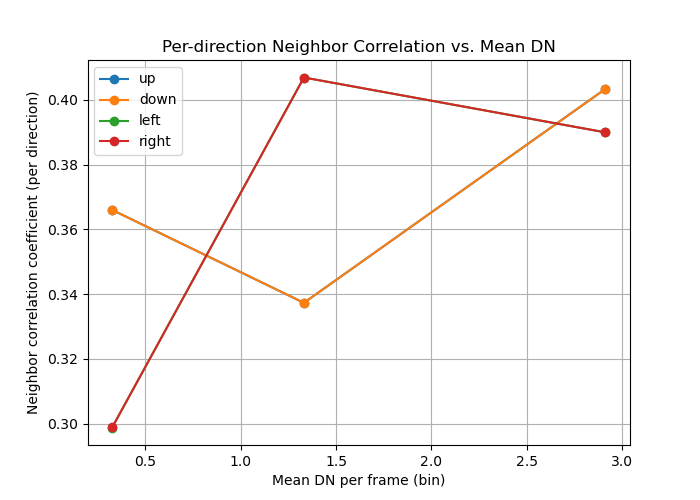

In [12]:
# Per-direction neighbor correlations
nn_corrs_all = []
for label in bin_labels:
    acf = bin_avg_acfs[label]
    if acf is not None:
        nn_vals = neighbor_corr(acf, directions_4)
        nn_corrs_all.append(nn_vals)
    else:
        nn_corrs_all.append([np.nan]*4)

nn_corrs_all = np.array(nn_corrs_all)  # shape: (n_bins, 4)

plt.figure(figsize=(7,5))
for i, d in enumerate(['up','down','left','right']):
    plt.plot(bin_mean_DNs, nn_corrs_all[:,i], marker='o', label=d)
plt.xlabel("Mean DN per frame (bin)")
plt.ylabel("Neighbor correlation coefficient (per direction)")
plt.title("Per-direction Neighbor Correlation vs. Mean DN")
plt.legend()
plt.grid(True)
plt.show()


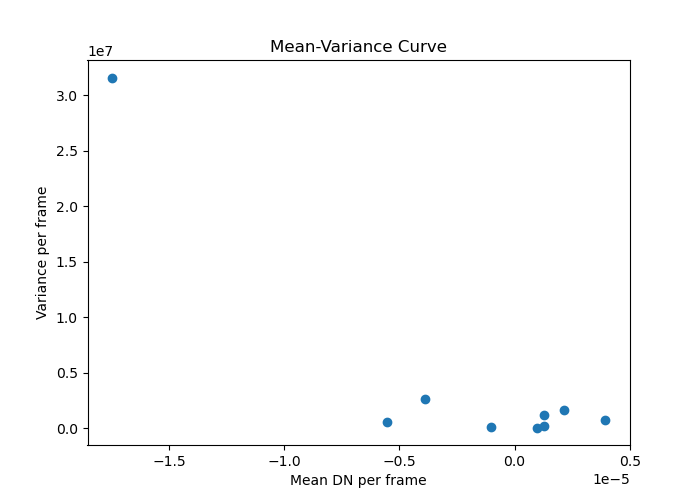

In [13]:

plt.figure(figsize=(7,5))
frame_means = [np.mean(f) for f in norm_frames_sorted]
frame_vars = [np.var(f) for f in norm_frames_sorted]
plt.scatter(frame_means, frame_vars)
plt.xlabel("Mean DN per frame")
plt.ylabel("Variance per frame")
plt.title("Mean-Variance Curve")
plt.show()


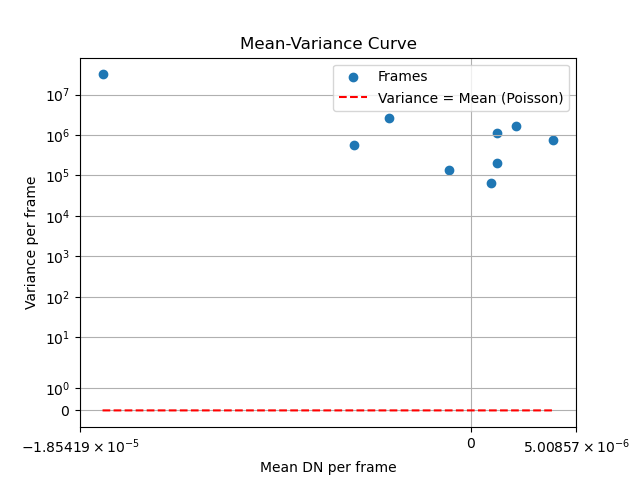

In [16]:
plt.figure()
# Plot all points
plt.scatter(frame_means, frame_vars, label='Frames')
# Poisson reference line
lims = [min(frame_means), max(frame_means)]
plt.plot(lims, lims, 'r--', label='Variance = Mean (Poisson)')
plt.xlabel("Mean DN per frame")
plt.ylabel("Variance per frame")
plt.title("Mean-Variance Curve")
plt.legend()
plt.grid(True)
plt.xscale('symlog')  # "symlog" handles zero/negatives better than "log"
plt.yscale('symlog')
plt.show()


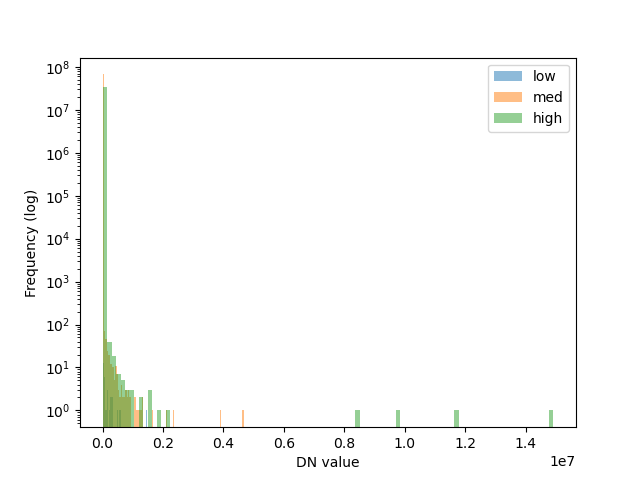

In [17]:
plt.figure()
for label, frames in binned_frames.items():
    if frames:
        all_vals = np.concatenate([f.ravel() for f in frames])
        plt.hist(all_vals, bins=100, log=True, alpha=0.5, label=label)
plt.xlabel("DN value")
plt.ylabel("Frequency (log)")
plt.legend()
plt.show()


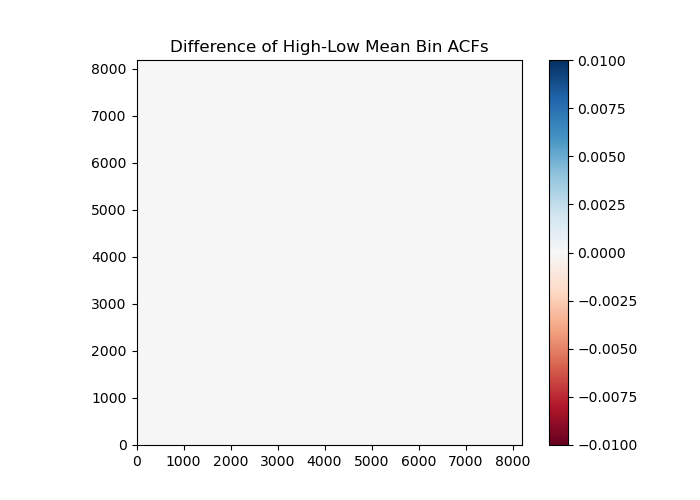

In [19]:
plt.close("all")
plt.figure(figsize=(7,5))
diff_map = bin_avg_acfs['high'] - bin_avg_acfs['low']
plt.imshow(diff_map, origin='lower', cmap='RdBu', vmin=-0.01, vmax=0.01)
plt.title("Difference of High-Low Mean Bin ACFs")
plt.colorbar()
plt.show()


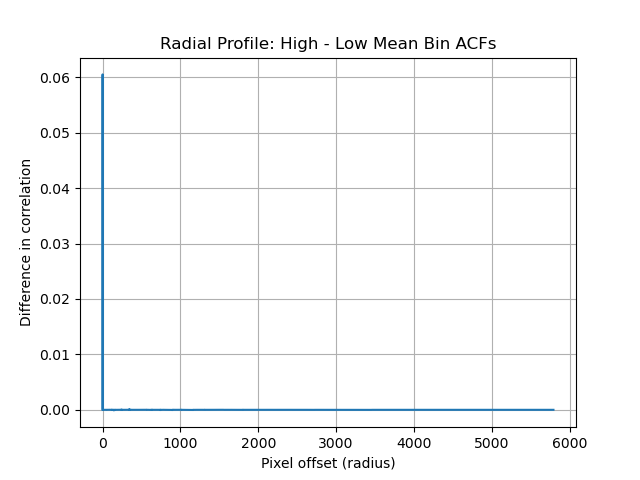

In [20]:
diff_map = bin_avg_acfs['high'] - bin_avg_acfs['low']
diff_profile = radial_profile(diff_map)
plt.figure()
plt.plot(diff_profile)
plt.xlabel('Pixel offset (radius)')
plt.ylabel('Difference in correlation')
plt.title('Radial Profile: High - Low Mean Bin ACFs')
plt.grid()
plt.show()


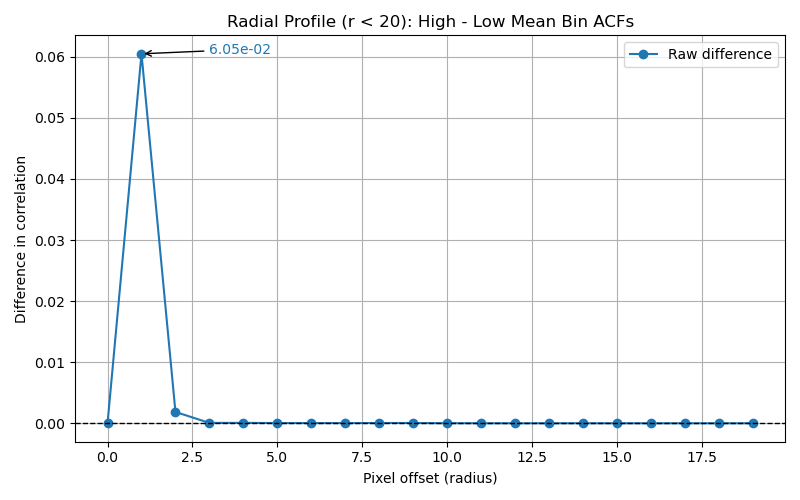

Delta correlation at center (radius=0): 0.00000e+00
Delta at nearest neighbor (radius=1): 6.05009e-02
Sum of difference profile (r<20): 6.26325e-02


In [24]:
from scipy.ndimage import uniform_filter1d

# ---- Parameters ----
zoom_radius = 20         # How many pixels out to plot
smoothing_width = 5      # Smoothing kernel for the rolling mean

# ---- Smoothing ----
#smoothed = uniform_filter1d(diff_profile, size=smoothing_width)

# ---- Plot ----
plt.figure(figsize=(8,5))
plt.plot(diff_profile[:zoom_radius], marker='o', label='Raw difference')
#plt.plot(smoothed[:zoom_radius], marker='s', label=f'Smoothed (width={smoothing_width})')
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Pixel offset (radius)')
plt.ylabel('Difference in correlation')
plt.title('Radial Profile (r < 20): High - Low Mean Bin ACFs')
plt.grid()
plt.legend()

# Annotate values at center and nearest neighbor
#plt.annotate(f'{diff_profile[0]:.2e}', xy=(0, diff_profile[0]), xytext=(2, diff_profile[0]+0.00005),
#             arrowprops=dict(arrowstyle='->', lw=1), color='C0')
plt.annotate(f'{diff_profile[1]:.2e}', xy=(1, diff_profile[1]), xytext=(3, diff_profile[1]+0.00005),
             arrowprops=dict(arrowstyle='->', lw=1), color='C0')

plt.tight_layout()
plt.show()

# ---- Print values at center and nearest neighbor ----
print(f"Delta correlation at center (radius=0): {diff_profile[0]:.5e}")
print(f"Delta at nearest neighbor (radius=1): {diff_profile[1]:.5e}")

# ---- Optionally: Area under curve as "total excess correlation" ----
area = np.sum(diff_profile[:zoom_radius])
print(f"Sum of difference profile (r<20): {area:.5e}")

In [26]:
from scipy.stats import linregress

gain_e_per_DN = 1.62  # Freudenburg et al gain for sca 20663

mean_e = np.array(bin_mean_DNs) * gain_e_per_DN
nn_corrs = np.array(nn_corrs)  #nearest neighbors correlations

# Fit only the first few bins if signal is low and linearity is expected
mask = ~np.isnan(mean_e) & ~np.isnan(nn_corrs)
slope, intercept, r_value, p_value, std_err = linregress(mean_e[mask], nn_corrs[mask])

print(f"Slope (alpha): {slope:.3e} per electron, intercept: {intercept:.3e}")


Slope (alpha): 1.483e-02 per electron, intercept: 3.304e-01


Power-law fit exponent gamma: 1.04


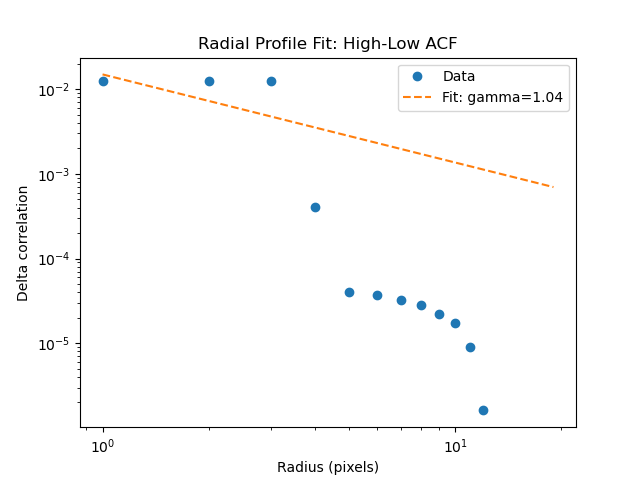

In [27]:
from scipy.optimize import curve_fit

def power_law(r, a, gamma):
    return a * r**(-gamma)

# Only fit where profile is >0 and r>1 (avoid central spike)
radii = np.arange(1, zoom_radius)
y = smoothed[1:zoom_radius]  # from your previous cell

pos = y > 0
popt, pcov = curve_fit(power_law, radii[pos], y[pos])
a_fit, gamma_fit = popt

print(f"Power-law fit exponent gamma: {gamma_fit:.2f}")

# Plot for visualization
plt.figure()
plt.loglog(radii, y, 'o', label='Data')
plt.loglog(radii, power_law(radii, *popt), '--', label=f'Fit: gamma={gamma_fit:.2f}')
plt.xlabel("Radius (pixels)")
plt.ylabel("Delta correlation")
plt.legend()
plt.title("Radial Profile Fit: High-Low ACF")
plt.show()


In [28]:
def compute_covariance(frames, lag=(1,0)):
    # lag: (dx, dy)
    frames = np.array(frames)
    N, H, W = frames.shape
    dx, dy = lag
    vals = []
    for frame in frames:
        mean = np.mean(frame)
        # Ensure we don't go out of bounds
        slice1 = frame[max(0, dx):H+min(0, dx), max(0, dy):W+min(0, dy)]
        slice2 = frame[max(0, -dx):H+min(0, -dx), max(0, -dy):W+min(0, -dy)]
        vals.append(np.mean((slice1 - mean) * (slice2 - mean)))
    return np.mean(vals)

lags = [ (0,1), (1,0), (0,-1), (-1,0) ] # 4 nearest neighbors
for label in bin_labels:
    frames = binned_frames[label]
    if frames:
        for lag in lags:
            cov = compute_covariance(frames, lag)
            print(f"Bin: {label}, lag {lag}, Covariance: {cov:.3e}")


Bin: low, lag (0, 1), Covariance: 3.930e+04
Bin: low, lag (1, 0), Covariance: 5.259e+04
Bin: low, lag (0, -1), Covariance: 3.930e+04
Bin: low, lag (-1, 0), Covariance: 5.259e+04
Bin: med, lag (0, 1), Covariance: 5.829e+05
Bin: med, lag (1, 0), Covariance: 4.215e+05
Bin: med, lag (0, -1), Covariance: 5.829e+05
Bin: med, lag (-1, 0), Covariance: 4.215e+05
Bin: high, lag (0, 1), Covariance: 8.223e+06
Bin: high, lag (1, 0), Covariance: 7.821e+06
Bin: high, lag (0, -1), Covariance: 8.223e+06
Bin: high, lag (-1, 0), Covariance: 7.821e+06


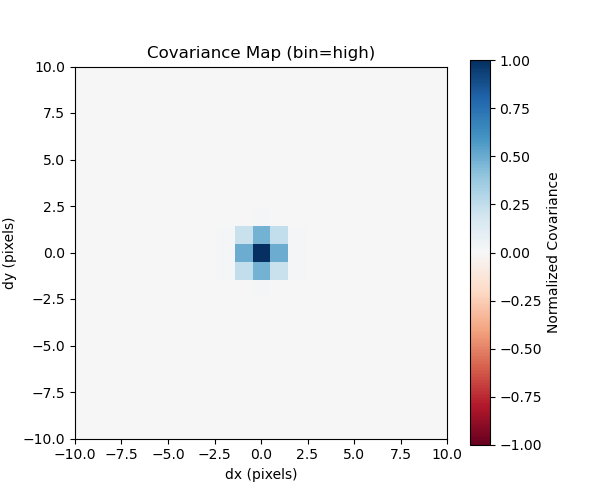

In [29]:

def compute_cov_map(frames, max_lag=10):
    # frames: list of 2D arrays
    N = max_lag * 2 + 1
    cov_map = np.zeros((N, N))
    center = (max_lag, max_lag)
    H, W = frames[0].shape

    for dx in range(-max_lag, max_lag+1):
        for dy in range(-max_lag, max_lag+1):
            vals = []
            for frame in frames:
                mean = np.mean(frame)
                # Slicing indices to avoid out-of-bounds
                x0, x1 = max(0, dx), H + min(0, dx)
                y0, y1 = max(0, dy), W + min(0, dy)
                xx0, xx1 = max(0, -dx), H + min(0, -dx)
                yy0, yy1 = max(0, -dy), W + min(0, -dy)
                slice1 = frame[x0:x1, y0:y1]
                slice2 = frame[xx0:xx1, yy0:yy1]
                vals.append(np.mean((slice1 - mean) * (slice2 - mean)))
            cov_map[center[0] + dx, center[1] + dy] = np.mean(vals)
    return cov_map

# Choose a bin (e.g., 'high')
bin_to_plot = 'high'
frames = binned_frames[bin_to_plot]
cov_map = compute_cov_map(frames, max_lag=10)

# Normalize for visualization (optional: divide by variance)
cov_map_norm = cov_map / np.max(np.abs(cov_map))

plt.figure(figsize=(6,5))
plt.imshow(cov_map_norm, cmap='RdBu', origin='lower',
           extent=[-10,10,-10,10], vmin=-1, vmax=1)
plt.colorbar(label='Normalized Covariance')
plt.title(f"Covariance Map (bin={bin_to_plot})")
plt.xlabel("dx (pixels)")
plt.ylabel("dy (pixels)")
plt.grid(False)
plt.show()
